In [1]:
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

### 이미지 캡셔닝 모델 및 프로세서 
- BLIP base 모델

In [23]:
from transformers import BlipProcessor, BlipForConditionalGeneration
MODEL_ID = 'Salesforce/blip-image-captioning-base'

processor = BlipProcessor.from_pretrained(MODEL_ID)
model = BlipForConditionalGeneration.from_pretrained(MODEL_ID)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f'총 파라메터 : {total_params}')
print(f'모델 데이터타입 : {next(model.parameters()).dtype}')
print(f'실행 디바이스 : {next(model.parameters()).device}')

총 파라메터 : 223971644
모델 데이터타입 : torch.float32
실행 디바이스 : cpu


이미지 크기 : (300, 168)(W x H)
이미지 모드 : RGB


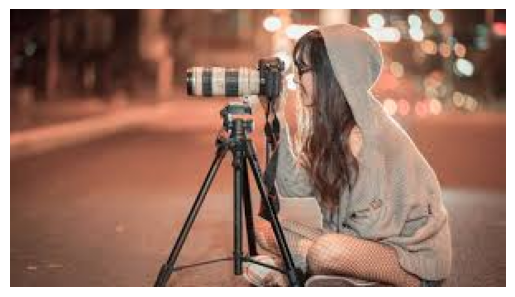

In [25]:
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
IMG_URL = 'demo1.jpg'
raw_image = Image.open(IMG_URL).convert('RGB')
print(f'이미지 크기 : {raw_image.size}(W x H)')
print(f'이미지 모드 : {raw_image.mode}')
plt.imshow(raw_image)      
plt.axis('off')
plt.show()

### Unconditaional 캡션 생성
- 프롬프트 없이 이미지만으로 자유로운 캡션을 생성

In [28]:
import torch
input = processor(raw_image, return_tensors='pt')
with torch.no_grad():
    output_ids = model.generate(
        **input,
        max_new_tokens=30
    )
caption_uncond = processor.decode(output_ids[0], skip_special_tokens=True)
print(caption_uncond)

a woman sitting on the ground


### Conditional 캡션 생성
- 프롬프트를 조건으로 특정 시작문구로 캡션을 유도하는 방식

In [ ]:
prompts = [
    'a photograpy of',
    'this image shows',
    'threr is'
]
conditional_resutls = []
for prompt in prompts:
    inputs = processor(raw_image,prompt, return_tensors='pt')
    with torch.no_grad():
        output_ids = model.generate(
            **input,
         max_new_tokens=30
    )
    caption = processor.decode(output_ids[0], skip_special_tokens=True)
    conditional_resutls.append((prompt, caption))
    print(f'프롬프트 : {prompt}')
    print(f'캡션 : {caption}')